In [1]:
import ImtaTURB as imta
import matplotlib.pyplot as plt

In [2]:
# Carga de datos
# Archivos 20 seg
file_p_20 = "Datos/OpenFOAM/20_cm/p"
file_U_20 = "Datos/OpenFOAM/20_cm/U"
# Archivos 30 seg
file_p_30 = "Datos/OpenFOAM/30_cm/p"
file_U_30 = "Datos/OpenFOAM/30_cm/U"
# Archivos 40 seg
file_p_40 = "Datos/OpenFOAM/40_cm/p"
file_U_40 = "Datos/OpenFOAM/40_cm/U"

Se extrajeron 168 probes.
Tiempo inicial: 0.00 s, tiempo final: 200.00 s
Duración de la muestra: 200.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)
Coordenadas probe 0: (0.37, 0.1, 0.3)
Componente r11: Frecuencia máxima = 0.697 Hz, Energía = 3.659e+06
Componente r12: Frecuencia máxima = 0.697 Hz, Energía = 3.962e+06
Componente r13: Frecuencia máxima = 0.053 Hz, Energía = 2.048e+05
Componente r22: Frecuencia máxima = 0.697 Hz, Energía = 4.290e+06
Componente r23: Frecuencia máxima = 0.697 Hz, Energía = 1.451e+05
Componente r33: Frecuencia máxima = 0.013 Hz, Energía = 4.581e+06


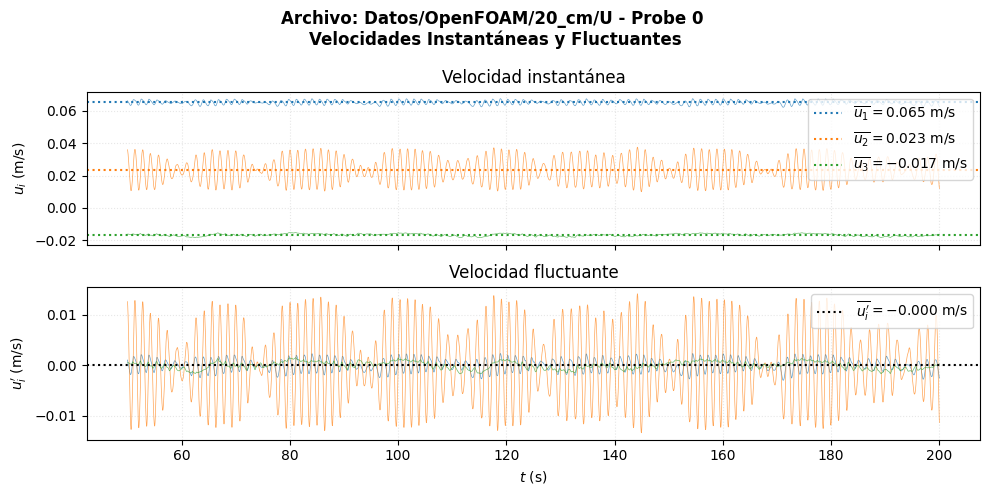

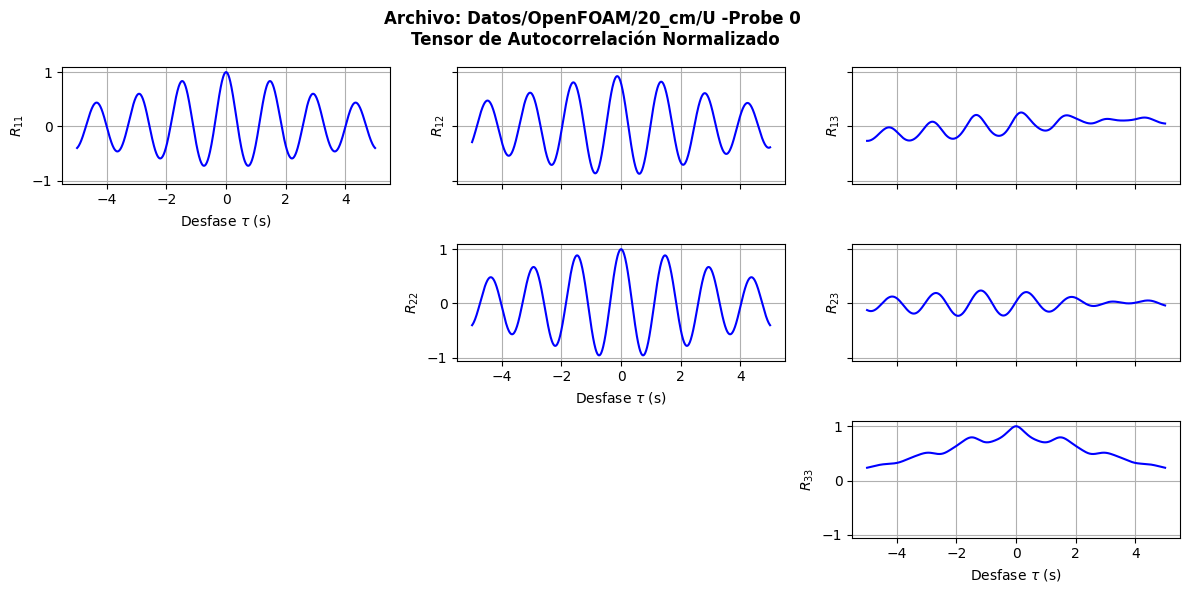

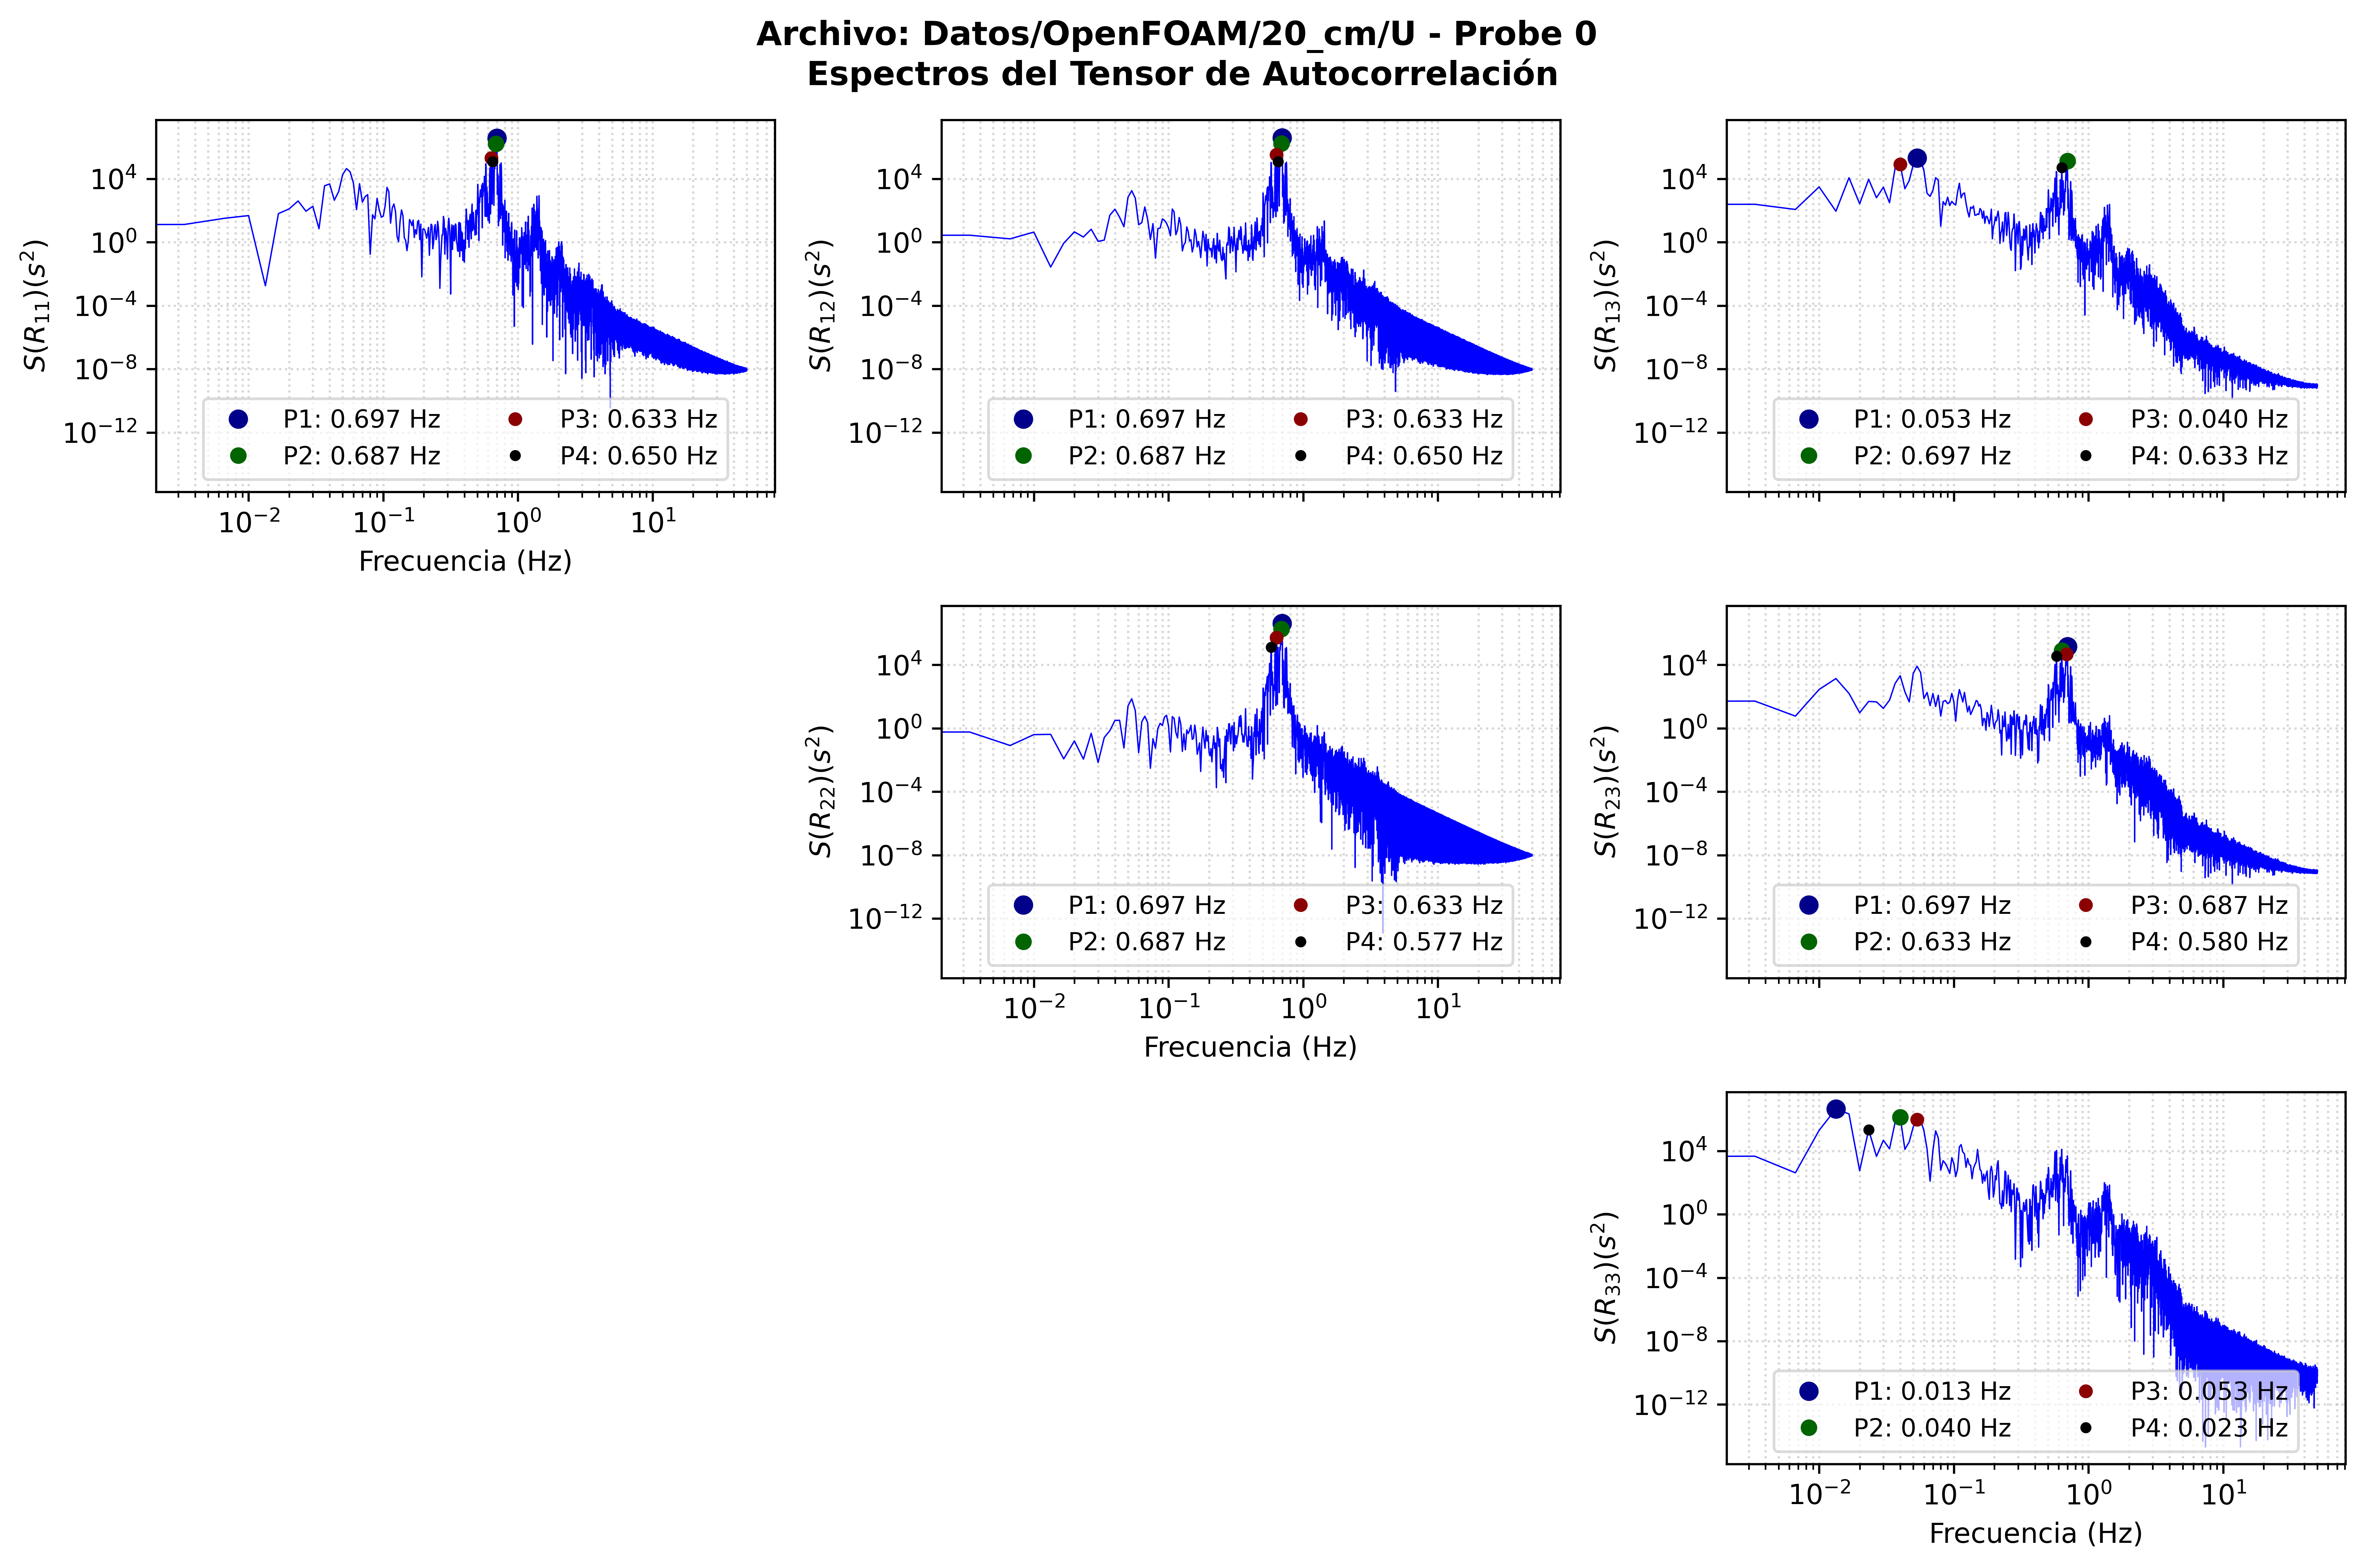

In [3]:
# Archivos 20 seg
U_probes, tiempo, coords, frecuencia = imta.cargar_U_OpenFOAM(file_U_20)
# Seleccionar un probe para análisis
probe = 0
inicio = 50
print(f"Coordenadas probe {probe}: {coords[probe]}")

# Tiempo de análisis
u1, u2, u3, tiempo, dfp_filt = imta.recortar_tiempo(U_probes, probe,
                                                    inicio= inicio)

# Velocidades fluctuantes 
u1_fluc, fig1 = imta.fluctuante(u1, tiempo=tiempo, plot=False, titulo='Velocidad u1')
u2_fluc, fig2 = imta.fluctuante(u2, tiempo=tiempo, plot=False, titulo='Velocidad u2')
u3_fluc, fig3 = imta.fluctuante(u3, tiempo=tiempo, plot=False, titulo='Velocidad u3')
imta.plot_ui(tiempo, u1_fluc, u2_fluc, u3_fluc,
            titulo=f'Archivo: {file_U_20} - Probe {probe} \nVelocidades Instantáneas y Fluctuantes',
            etiquetas=('u_1', 'u_2', 'u_3'));
# Autocorrelación Normalizada
tensor_r, lags_s, fig = imta.autocorrelacion_norm(u1_fluc['fluc'],
                                                  u2_fluc['fluc'],
                                                  u3_fluc['fluc'],
                                                  frecuencia,
                                                  plot=True,
                                                  titulo=f'Archivo: {file_U_20} -Probe {probe} \nTensor de Autocorrelación Normalizado',
                                                  max_lag_seg=5.0)
# Espectros
frecuencias, espectro, fig = imta.espectros_tensor(tensor_r,
                                                   frecuencia,
                                                   titulo=f'Archivo: {file_U_20} - Probe {probe} \nEspectros del Tensor de Autocorrelación',
                                                   plot=True)

Se extrajeron 168 probes.
Tiempo inicial: 0.00 s, tiempo final: 200.00 s
Duración de la muestra: 200.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)


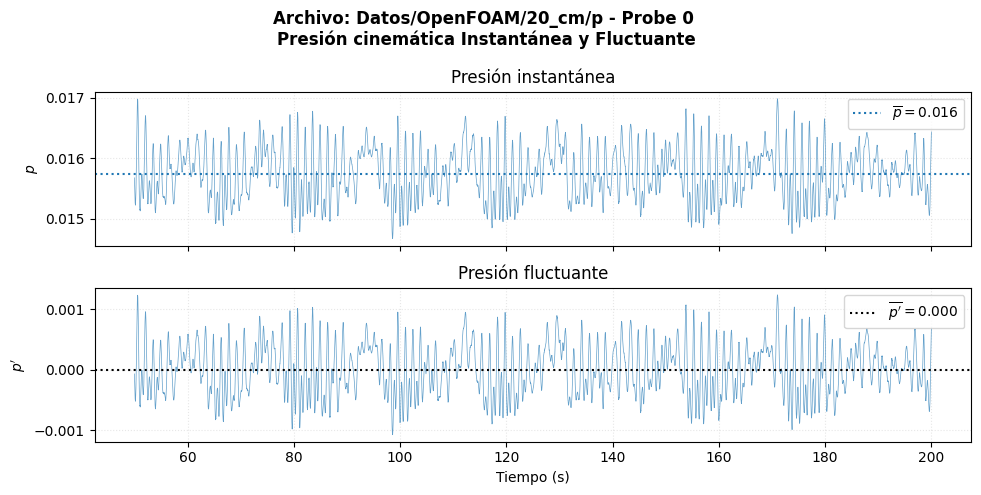

In [4]:
p_probes, tiempo_p, coords_p, fs_p = imta.cargar_p_OpenFOAM(file_p_20)
# Visualización de señal de presión
p1, t1, _ = imta.recortar_tiempo(p_probes, probe=probe, inicio=inicio)
p1_fluc, _ = imta.fluctuante(p1, tiempo=t1)
imta.plot_p(t1, p1_fluc,
            titulo=f'Archivo: {file_p_20} - Probe {probe} \nPresión cinemática Instantánea y Fluctuante',
            etiqueta='p');


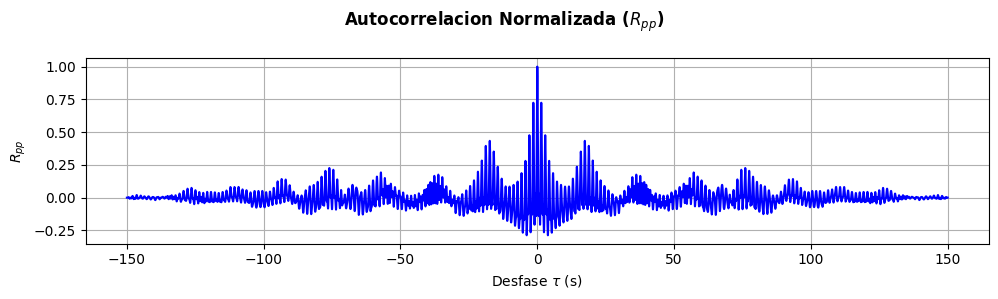

In [5]:
R_p, lags, _ = imta.autocorrelacion_norm(
    p1_fluc['fluc'], frecuencia=100, plot=True, max_lag_seg=150)